In [1]:
# =======================================================
# NOTEBOOK 3: XGBOOST CAMPEÃO + AVALIAÇÃO OFICIAL
# =======================================================
import numpy as np
import pandas as pd
import xgboost as xgb
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# 1. FUNÇÕES DO JUIZ (O SCORE DO SEU COLEGA)
# -------------------------------------------------------
def norm_f(m, a=4443.76, b=1.53, c=4443.76, d=0):
    return (a / ((m**b) + c)) + d

def calcular_score(df_resultados, alpha_peso=2.0):
    resultados_viagem = []

    for trem_id, df_trem in df_resultados.groupby('ID_Trem'):
        T = len(df_trem)
        if T == 0: continue
        
        df_trem = df_trem.sort_values('Ciclo_Atual')
        erro_t = df_trem['RUL_Real'] - df_trem['RUL_Final'] 
        
        # SDE
        erro_medio = erro_t.mean() 
        diferencas_quadradas = (erro_t - erro_medio) ** 2 
        somatorio = np.sum(diferencas_quadradas)
        metric_val = np.sqrt(somatorio / T)

        # RMSE
        erro_quadrado = erro_t ** 2 
        somatorio = np.sum(erro_quadrado)
        mse = somatorio / T
        rmse_val = np.sqrt(mse)

        # NORMALIZAÇÃO
        sde_norm = norm_f(metric_val)
        rmse_norm = norm_f(rmse_val)
        
        # ACCURACY
        erro_absoluto = np.abs(df_trem['RUL_Real'] - df_trem['RUL_Final']) 
        rul_real = np.maximum(df_trem['RUL_Real'], 1e-5) 
        expoente = -(erro_absoluto / rul_real) 
        valores_exponenciais = np.exp(expoente) 
        acc_val = valores_exponenciais.mean() 

        # PROGNOSTIC HORIZON (PH)
        t_eof = df_trem['Ciclo_Atual'].max() 
        margem_constante = t_eof * 0.10
        limite_inferior = df_trem['RUL_Real'] - margem_constante
        limite_superior = df_trem['RUL_Real'] + margem_constante
        
        dentro_limites = (df_trem['RUL_Final'] >= limite_inferior) & (df_trem['RUL_Final'] <= limite_superior)
        fora_limites = ~dentro_limites 
        
        if fora_limites.any():
            ultimo_erro = df_trem.loc[fora_limites, 'Ciclo_Atual'].max()
            df_reta_final = df_trem[df_trem['Ciclo_Atual'] > ultimo_erro]
            t_alpha = t_eof if df_reta_final.empty else df_reta_final['Ciclo_Atual'].min()
        else:
            t_alpha = df_trem['Ciclo_Atual'].min()
                
        ph = (t_eof - t_alpha) / t_eof if t_eof > 0 else 0
        score = (rmse_norm + sde_norm + (alpha_peso * ph)) / (2 + alpha_peso)

        resultados_viagem.append({
            'ID_Trem': trem_id,
            'T_Pontos': T,
            'Erro_Medio': round(erro_medio, 2),
            'RMSE_Bruto': round(rmse_val, 2),
            'Accuracy': round(acc_val, 4),
            'PH': round(ph, 4),
            'Score': round(score, 4)
        })

    df_metricas = pd.DataFrame(resultados_viagem)
    print("\n--- Métricas Individuais por Trem (Validação) ---")
    print(df_metricas.to_string(index=False))
    print("\n" + "="*70)
    print(f" 🏆 SCORE MÉDIO FINAL: {df_metricas['Score'].mean():.4f} | PH Médio: {df_metricas['PH'].mean():.4f}")
    print("="*70)

# -------------------------------------------------------
# 2. CARREGAMENTO DOS NOVOS DADOS (Sinais Vitais Mecânicos)
# -------------------------------------------------------
print("1. Carregando o Dataset V3 (com Janelas Deslizantes)...")
df_ml = pd.read_csv('dataset_features_v3.csv')

# Usamos apenas os grupos de Treino e Validação para medir o desempenho agora
df_treino = df_ml[df_ml['Grupo'] == 'Treino'].copy()
df_val = df_ml[df_ml['Grupo'] == 'Validação'].copy()

# AQUI ESTÁ O PODER: As nossas novas features de janela!
features = [
    'Distancia_Ref_Atual', 'Inclinacao_Mecanica', 
    'Vibracao_Max', 'Vibracao_Media', 'Vibracao_Tendencia', 
    'Vibracao_Std', 'Vibracao_Kurtosis', 'Vibracao_Energia'
]

X_train = df_treino[features]
y_train_bruto = df_treino['RUL_Alvo'].values

X_test = df_val[features]
y_test_bruto = df_val['RUL_Alvo'].values

# O Cap fixo do seu colega (400 viagens)
rul_maximo = 400
y_train = np.clip(y_train_bruto, a_min=0, a_max=rul_maximo)
y_test = np.clip(y_test_bruto, a_min=0, a_max=rul_maximo)

# -------------------------------------------------------
# 3. TREINAMENTO DO MODELO CAMPEÃO
# -------------------------------------------------------
print("2. Treinando o XGBoost com as features de alta resolução...")
modelo_xgb = xgb.XGBRegressor(
    n_estimators=300, 
    max_depth=4, 
    learning_rate=0.05, 
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
modelo_xgb.fit(X_train, y_train)

# -------------------------------------------------------
# 4. APLICAÇÃO DOS FILTROS (EMA + Monotônico)
# -------------------------------------------------------
print("3. Aplicando Filtros de Suavização Industriais...")
previsoes_brutas = modelo_xgb.predict(X_test)

# Trava específica: Se a IA disser que falta mais de 360, arredonda logo pra 400 (Porta Nova)
previsoes_brutas = np.where(previsoes_brutas > 360, 400, previsoes_brutas)

df_resultados = pd.DataFrame({
    'ID_Trem': df_val['ID_Trem'],
    'Ciclo_Atual': df_val['Ciclo'],
    'RUL_Real': y_test,               
    'RUL_Real_Bruto': y_test_bruto,   
    'RUL_Previsto_Bruto': previsoes_brutas,
})

df_resultados = df_resultados.sort_values(['ID_Trem', 'Ciclo_Atual'])

# Filtro 1: EMA curtíssimo (span=3) - Responde rápido a mudanças bruscas
df_resultados['RUL_Suavizado'] = df_resultados.groupby('ID_Trem')['RUL_Previsto_Bruto'].transform(
    lambda x: x.ewm(span=3, adjust=False).mean()
)
# Filtro 2: Trava de Segurança Monotônica (A porta não pode "des-quebrar")
df_resultados['RUL_Final'] = df_resultados.groupby('ID_Trem')['RUL_Suavizado'].cummin()

calcular_score(df_resultados)

# -------------------------------------------------------
# 5. TABELAS VISUAIS NO NAVEGADOR (PLOTLY)
# -------------------------------------------------------
print("\n4. Gerando as Tabelas Visuais Interativas...")
ids_teste = df_val['ID_Trem'].unique()

for trem_escolhido in ids_teste[:4]: # Mostra apenas as 4 primeiras portas para não travar o PC
    df_trem = df_resultados[df_resultados['ID_Trem'] == trem_escolhido].copy().sort_values('Ciclo_Atual')
    if df_trem.empty: continue
        
    df_trem['t'] = df_trem['Ciclo_Atual'] - df_trem['Ciclo_Atual'].min()
    df_trem['RUL real'] = df_trem['RUL_Real_Bruto'] 
    df_trem['RUL predito'] = df_trem['RUL_Final'].round(2)
    
    t_eol_viagem = df_trem['RUL real'].iloc[0]
    alpha_val = t_eol_viagem * 0.10
    
    df_trem['+alpha'] = (df_trem['RUL real'] + alpha_val).round(1)
    df_trem['-alpha'] = (df_trem['RUL real'] - alpha_val).round(1)
    df_trem = df_trem.reset_index(drop=True)
    
    esta_na_banda = (df_trem['RUL predito'] >= df_trem['-alpha']) & (df_trem['RUL predito'] <= df_trem['+alpha'])
    
    if esta_na_banda.any():
        idx_acerto = esta_na_banda.idxmax()
        t_alpha_val = df_trem.loc[idx_acerto, 't']
        status_texto = f"<span style='color: #27ae60;'>Acerto no t={t_alpha_val}</span>"
    else:
        idx_acerto = float('inf') 
        t_alpha_val = "NaN"
        status_texto = "<span style='color: #c0392b;'>Nunca entrou na margem</span>"

    cores_linhas = []
    for i in range(len(df_trem)):
        if i >= idx_acerto:
            cores_linhas.append('#e8f5e9' if i % 2 == 0 else '#d4edda') 
        else:
            cores_linhas.append('white' if i % 2 == 0 else '#f2f7f9')

    tabela_final = df_trem[['t', 'RUL real', 'RUL predito', '+alpha', '-alpha']]
    matriz_cores = [cores_linhas] * len(tabela_final.columns)

    titulo_tabela = (
        f"<b>DIAGNÓSTICO DA VIAGEM - TREM {trem_escolhido}</b><br>"
        f"<sup style='font-size: 14px;'>t_EoL: {t_eol_viagem:.0f} ciclos | Margem (&alpha;): &plusmn;{alpha_val:.1f} | t_alpha: {status_texto}</sup>"
    )

    fig = go.Figure(data=[go.Table(
        header=dict(
            values=[f"<b>{col}</b>" for col in tabela_final.columns],
            line_color='darkslategray', fill_color='#2c3e50', 
            align='center', font=dict(color='white', size=14), height=40
        ),
        cells=dict(
            values=[tabela_final[col] for col in tabela_final.columns],
            line_color='darkslategray', fill_color=matriz_cores, 
            align='center', font=dict(color='darkslategray', size=13), height=30
        )
    )])

    fig.update_layout(
        title_text=titulo_tabela, title_x=0.5, 
        margin=dict(l=20, r=20, t=80, b=20), width=900, height=600 
    )
    fig.show(renderer='browser')

# -------------------------------------------------------
# 6. EXPORTAÇÃO DO ARQUIVO DE SUBMISSÃO
# -------------------------------------------------------
print("\n5. Gerando arquivo final de submissão...")
df_submissao = df_resultados[['ID_Trem', 'RUL_Final']].copy()
df_submissao['RUL_Final'] = df_submissao['RUL_Final'].round(0).astype(int)
df_submissao.columns = ['Test_ID', 'RUL']

nome_arquivo = 'submission_xgboost_phm_V3.csv'
df_submissao.to_csv(nome_arquivo, index=False, header=False) 

print(f"✅ Arquivo '{nome_arquivo}' gerado com sucesso na sua pasta!")

1. Carregando o Dataset V3 (com Janelas Deslizantes)...
2. Treinando o XGBoost com as features de alta resolução...
3. Aplicando Filtros de Suavização Industriais...

--- Métricas Individuais por Trem (Validação) ---
 ID_Trem  T_Pontos  Erro_Medio  RMSE_Bruto  Accuracy     PH  Score
       1       192       20.25       45.31    0.8838 0.2886 0.6112
      12       297       38.24       64.43    0.8730 0.2418 0.5702
      13       152       55.75       85.57    0.8024 0.3106 0.5836
      20       424       52.79       83.33    0.8621 0.9769 0.9184
      21       141      -10.74       24.45    0.8705 0.9333 0.9532
      27       173       -5.96       26.16    0.9127 0.2253 0.5969
      28        86        1.00       28.42    0.8714 0.5789 0.7713
      46       192       -3.34       24.05    0.9033 0.9502 0.9610
      48       152        7.92       30.19    0.8922 0.2857 0.6235

 🏆 SCORE MÉDIO FINAL: 0.7321 | PH Médio: 0.5324

4. Gerando as Tabelas Visuais Interativas...

5. Gerando arquiv

Gerando o Painel de Avaliação da Frota...


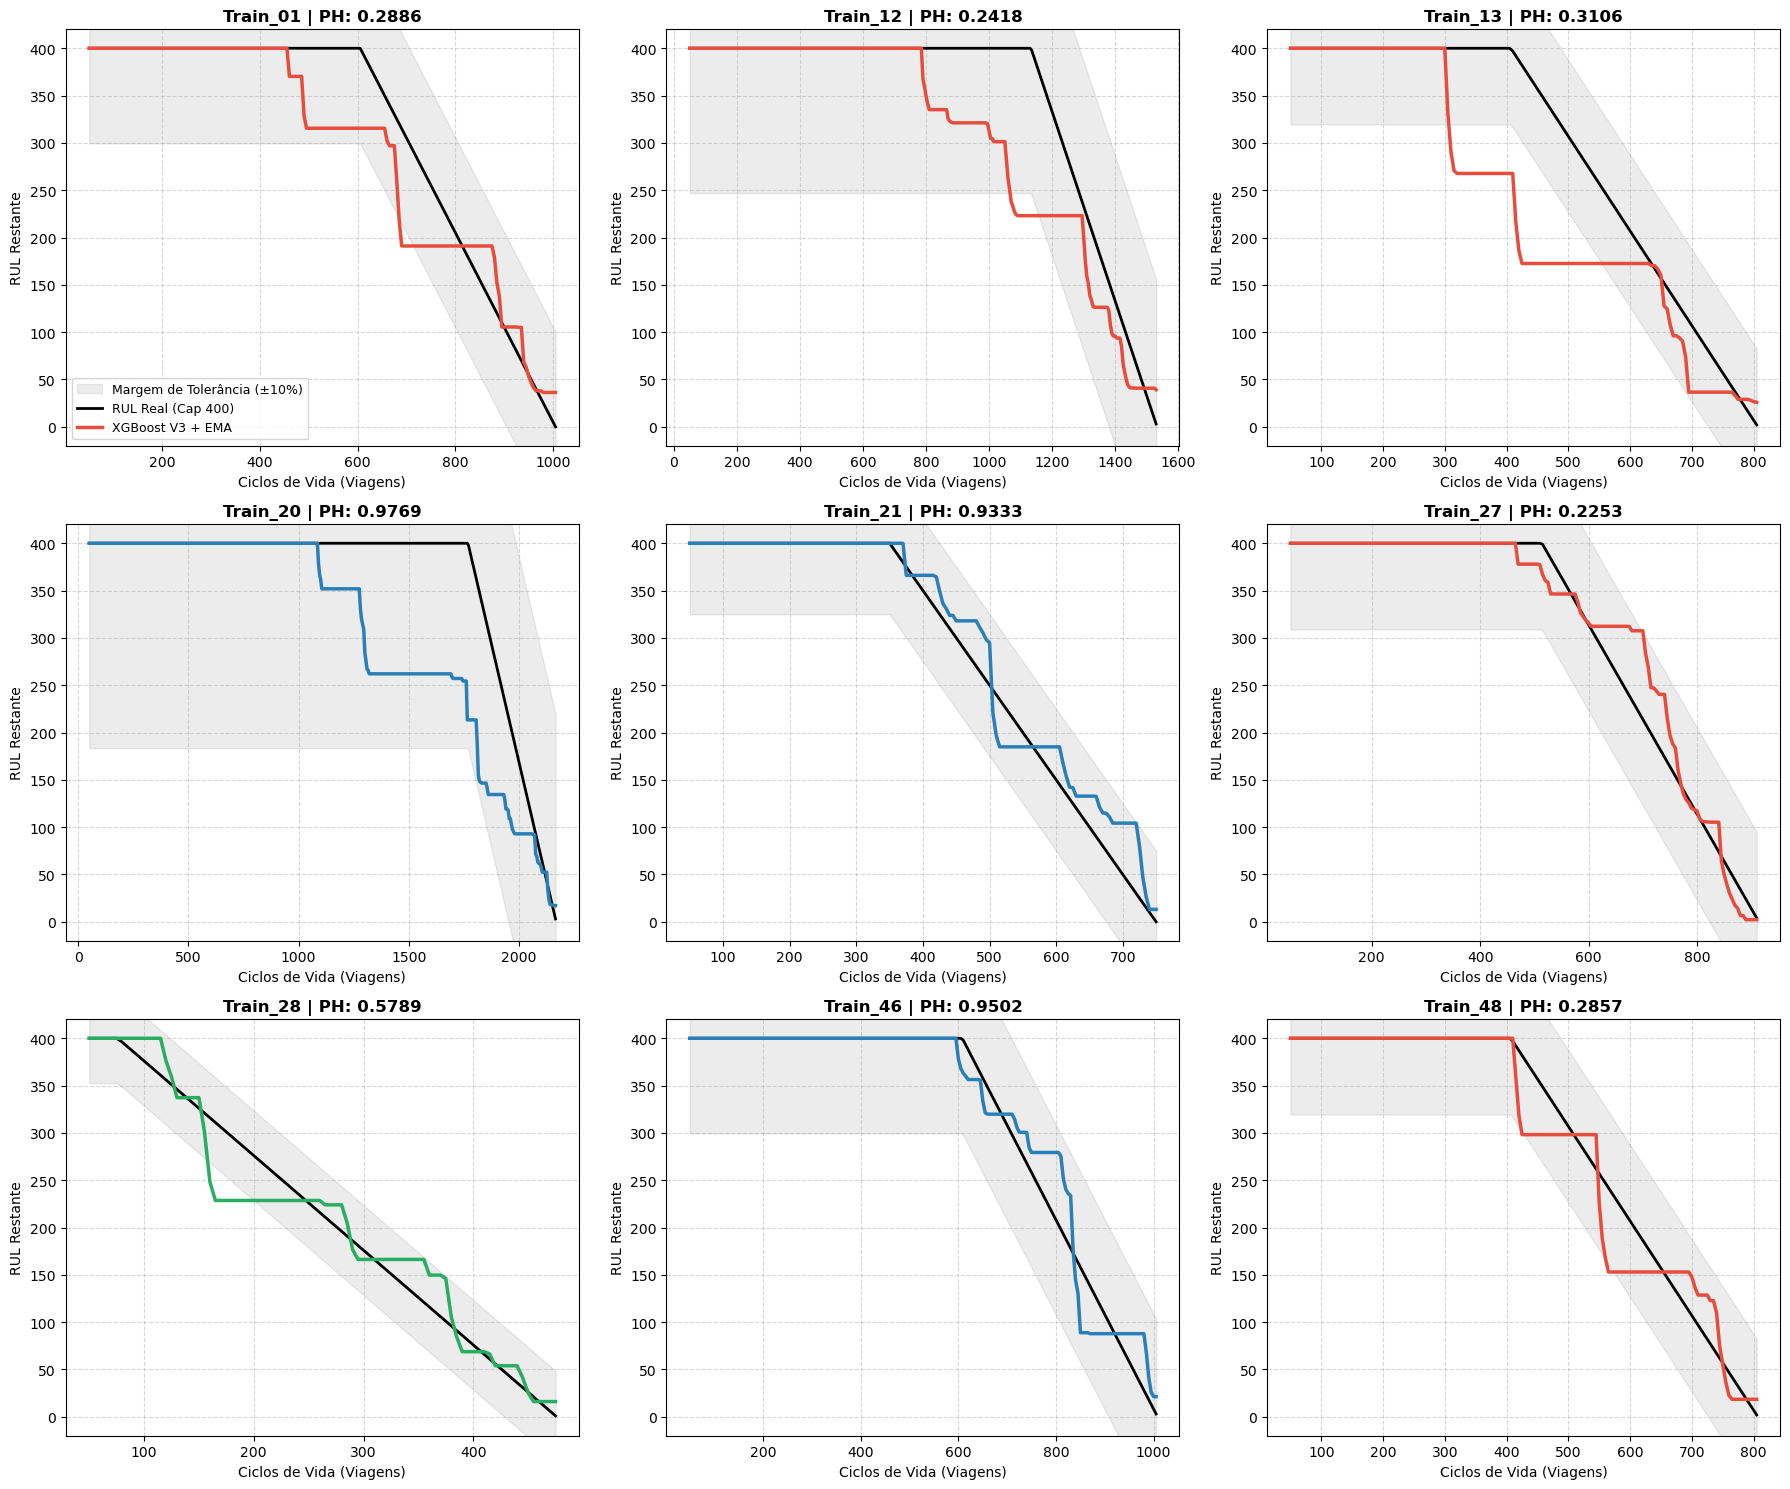

In [2]:
# =======================================================
# 7. O PAINEL DE RAIO-X: RUL REAL VS PREDITO (COM MARGEM DO JUIZ)
# =======================================================
import matplotlib.pyplot as plt
import numpy as np

# Pegando a lista de trens que estão no df_resultados
trens_validacao = df_resultados['ID_Trem'].unique()

num_trens = len(trens_validacao)
cols = 3
rows = int(np.ceil(num_trens / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

print("Gerando o Painel de Avaliação da Frota...")

for idx, trem in enumerate(trens_validacao):
    df_trem = df_resultados[df_resultados['ID_Trem'] == trem].sort_values(by='Ciclo_Atual')
    
    ciclos = df_trem['Ciclo_Atual'].values
    y_real = df_trem['RUL_Real'].values
    y_pred = df_trem['RUL_Final'].values
    
    # Recalculando a Margem do Juiz e o PH para este trem
    t_eof = ciclos.max() 
    margem_constante = t_eof * 0.10
    limite_inferior = y_real - margem_constante
    limite_superior = y_real + margem_constante
    
    dentro_limites = (y_pred >= limite_inferior) & (y_pred <= limite_superior)
    fora_limites = ~dentro_limites 
    
    if fora_limites.any():
        ultimo_erro = df_trem.loc[fora_limites, 'Ciclo_Atual'].max()
        df_reta_final = df_trem[df_trem['Ciclo_Atual'] > ultimo_erro]
        t_alpha = t_eof if df_reta_final.empty else df_reta_final['Ciclo_Atual'].min()
    else:
        t_alpha = df_trem['Ciclo_Atual'].min()
            
    ph = (t_eof - t_alpha) / t_eof if t_eof > 0 else 0
    
    # --- DESENHANDO O GRÁFICO ---
    ax = axes[idx]
    
    # 1. A Faixa Cinza (A Margem de Acerto do Juiz)
    ax.fill_between(ciclos, limite_inferior, limite_superior, color='gray', alpha=0.15, label='Margem de Tolerância (±10%)')
    
    # 2. O Gabarito Real (Linha Preta)
    ax.plot(ciclos, y_real, color='black', linewidth=2, label='RUL Real (Cap 400)')
    
    # 3. A Previsão do nosso Modelo (Linha Verde/Azul)
    # Se o PH for excelente (>0.8), pinto de azul. Se for bom (>0.4), verde. Se for ruim, vermelho.
    cor_linha = '#2980b9' if ph > 0.8 else ('#27ae60' if ph > 0.4 else '#e74c3c')
    ax.plot(ciclos, y_pred, color=cor_linha, linewidth=2.5, linestyle='-', label='XGBoost V3 + EMA')
    
    ax.set_title(f'Train_{trem:02d} | PH: {ph:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ciclos de Vida (Viagens)', fontsize=10)
    ax.set_ylabel('RUL Restante', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Limitando o eixo Y para não ficar negativo visualmente
    ax.set_ylim(-20, 420)
    
    if idx == 0:
        ax.legend(fontsize=9)

# Apagando os gráficos vazios que sobrarem no grid
for i in range(num_trens, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()